# Principal Component Analysis (PCA) on Employee_data

The goal of Principal Component Analysis (PCA) is to reduce the **number of dimensions** of a d-dimensional dataset by projecting it onto a k-dimensional subspace (with k < d) in order to increase the **computational efficiency** while retaining most of the information.

The k dimensions that we keep (eigenvectors) are called "**principal components**".

The PCA approach requires to:

* Standardize the data.
* Obtain the Eigenvectors and Eigenvalues from a Singular Vector Decomposition (SVD) of the data matrix.
* Choose the number k of principal components to keep.
* Construct a projection matrix with the selected k eigenvectors.
* Project original dataset to a k-dimensional feature subspace.

Choosing the number k can be done systematically by selecting the components that best describe the variance in our data. The amount of information (variance) contained by each eigenvector can be measured by the **explained variance**.

This notebook will display the explained variance for your dataset and help you choose the right amount of eigenvectors ("principal components").

* [Setup and loading the data](#setup)
* [Preprocessing of the data](#preprocessing)
* [Computation of the PCA](#pca)
* [Display of the explained variance](#explained-variance)
* [Retaining of the most significant components](#final-pca)
* [Visualizing the vectors in the original space](#original-space)

## Setup and dataset loading <a id="setup" />

First of all, let's load the libraries that we'll use

In [1]:
import sys
import pandas as pd, numpy as np             # Data manipulation
from sklearn.decomposition import PCA        # The main algorithm
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from collections import defaultdict, Counter # Utils
sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

The first thing we do is now to load the dataset and put aside the three main types of columns:

* Numerical
* Categorical
* Date

Since analyzing PCA requires to have the data in memory, we are only going to load a sample of the data. Modify the following cell to change the size of the sample.

Also, by default, date features are not kept. Modify the following cell to change that.

In [2]:
# load the data file
df_orig = pd.read_excel('https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/15%20Dimension_reduction_PCA/Employee_data.xlsx', index_col=0)
df_orig.head()

,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority,age
id,,,,,,,,,,
0,m,1952-02-03 00:00:00,15,Manager,57000,27000,98,144,0,61.0
1,m,1958-05-23 00:00:00,16,Clerical,40200,18750,98,36,0,55.0
2,f,1929-07-26 00:00:00,12,Clerical,21450,12000,98,381,0,84.0
3,f,1947-04-15 00:00:00,8,Clerical,21900,13200,98,190,0,66.0
4,m,1955-02-09 00:00:00,15,Clerical,45000,21000,98,138,0,58.0


In [3]:
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474 entries, 0 to 473
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    474 non-null    object 
 1   bdate     474 non-null    object 
 2   educ      474 non-null    int64  
 3   jobcat    474 non-null    object 
 4   salary    474 non-null    int64  
 5   salbegin  474 non-null    int64  
 6   jobtime   474 non-null    int64  
 7   prevexp   474 non-null    int64  
 8   minority  474 non-null    int64  
 9   age       473 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 40.7+ KB


We can explore the number of unique categorical values

In [4]:
print(set(df_orig["jobcat"]))

{'Clerical', 'Manager', 'Technical'}


In [5]:
# make a copy of the original dataframe
df = df_orig.copy()

# Get the column names
numerical_columns = list(df.select_dtypes(include=[np.number]).columns)
categorical_columns = list(df.select_dtypes(include=[object]).columns)
date_columns = list(df.select_dtypes(include=['<M8[ns]']).columns)

# Print a quick summary of what we just loaded
print("Loaded dataset")
print("   Rows: %s" % df.shape[0])
print("   Columns: %s (%s num, %s cat, %s date)" % (df.shape[1],
                                                    len(numerical_columns), len(categorical_columns),
                                                    len(date_columns)))

Loaded dataset
   Rows: 474
   Columns: 10 (7 num, 3 cat, 0 date)


## Preprocessing of the data <a id="preprocessing" />

Get rid of the columns that contain too many unique values

In [6]:
DROP_LIMIT_ABS = 10
CAT_DROP_LIMIT_RATIO = 0.5
columns_to_drop = []

categorical_columns = list(df.select_dtypes(include=[object]).columns)

for feature in categorical_columns:
    nu = df[feature].nunique()

    if nu > DROP_LIMIT_ABS or nu > CAT_DROP_LIMIT_RATIO * df.shape[0]:
        print("Dropping feature %s with %s unique values (too many)" % (feature, nu))
        columns_to_drop.append(feature)

# Ensure columns_to_drop contains only unique values after this step
columns_to_drop = list(set(columns_to_drop))
print("Final columns to drop: %s" % columns_to_drop)

Dropping feature bdate with 462 unique values (too many)
Final columns to drop: ['bdate']


We then need to impute missing values (or drop the records)

In [7]:
impute = True # you can change this

if impute:
    # Separate numerical and categorical columns for imputation
    numerical_cols_for_imputation = [col for col in numerical_columns if col not in columns_to_drop]
    categorical_cols_for_imputation = [col for col in categorical_columns if col not in columns_to_drop and col in df.columns]

    # Use mean for numerical features
    for feature in numerical_cols_for_imputation:
        v = df[feature].mean()
        if np.isnan(v):
            v = 0 # Fallback for entirely NaN columns
        print("Filling numerical feature %s with %s" % (feature, v))
        df[feature] = df[feature].fillna(v)

    # Use mode for categorical features
    for feature in categorical_cols_for_imputation:
        if not df[feature].empty and not df[feature].mode().empty:
            v = df[feature].mode()[0]
            print("Filling categorical feature %s with mode %s" % (feature, v))
            df[feature] = df[feature].fillna(v)
        else:
            print(f"Warning: Categorical feature {feature} is empty or has no mode; skipping imputation.")

else:
    # drop records
    df.dropna(inplace=True)

Filling numerical feature educ with 13.4915611814346
Filling numerical feature salary with 34419.56751054852
Filling numerical feature salbegin with 17016.086497890294
Filling numerical feature jobtime with 81.1097046413502
Filling numerical feature prevexp with 95.86075949367088
Filling numerical feature minority with 0.21940928270042195
Filling numerical feature age with 56.76955602536998
Filling categorical feature gender with mode m
Filling categorical feature jobcat with mode Clerical


Drop the columns

In [8]:
print("Dropping the following columns: %s" % columns_to_drop)
df = df.drop(columns_to_drop, axis=1, errors='ignore')

# Update column lists after dropping
numerical_columns = list(df.select_dtypes(include=[np.number]).columns)
categorical_columns = list(df.select_dtypes(include=[object]).columns)
date_columns = list(df.select_dtypes(include=['<M8[ns]']).columns) # Should be empty if `keep_dates` is False and they were dropped

Dropping the following columns: ['bdate']


For all categorical features, we are going to "dummy-encode" them (one-hot encoding). <BR>We consider a categorical variable the ones with object data type from the original dataset. <BR> We could also remove less frequent categories to avoid creating an excessive number of dummy variables for high-cardinality categorical features


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify numerical and categorical features remaining after initial drops/imputations
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()

# Create preprocessing steps for numerical and categorical features
# Numerical features will be scaled
# Categorical features will be one-hot encoded, ignoring unknown categories to prevent errors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a dummy pipeline to fit and transform the data
# We'll use this transformed data for PCA directly.
# PCA will be applied separately after this preprocessing step.
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_processed = pipeline.fit_transform(df)

# Get feature names after one-hot encoding for later use (e.g., in factor loadings)
encoded_feature_names = \
    (preprocessor.named_transformers_['num'].get_feature_names_out(numerical_features).tolist() if numerical_features else []) + \
    (preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist() if categorical_features else [])

# Convert processed data back to a DataFrame for easier handling, if needed
X_std_df = pd.DataFrame(X_processed, columns=encoded_feature_names, index=df.index)

# The variable `X_std` used in subsequent PCA cells now corresponds to X_processed
X_std = X_processed
print("Data preprocessed using ColumnTransformer and OneHotEncoder/StandardScaler.")
print(f"Original features: {df.shape[1]}")
print(f"Processed features: {X_std_df.shape[1]}")

# Update df to reflect the preprocessed data (for consistency with original notebook flow)
# Note: This effectively replaces the original df with the preprocessed version.
# If you need to keep original df, make a copy earlier.
df = X_std_df

Data preprocessed using ColumnTransformer and OneHotEncoder/StandardScaler.
Original features: 9
Processed features: 12


In [10]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['educ', 'salary', 'salbegin',
                                                   'jobtime', 'prevexp',
                                                   'minority', 'age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'jobcat'])]))])

In [11]:
print(df.columns)

Index(['educ', 'salary', 'salbegin', 'jobtime', 'prevexp', 'minority', 'age',
       'gender_f', 'gender_m', 'jobcat_Clerical', 'jobcat_Manager',
       'jobcat_Technical'],
      dtype='object')


In [12]:
display(df.head())

,educ,salary,salbegin,jobtime,prevexp,minority,age,gender_f,gender_m,jobcat_Clerical,jobcat_Manager,jobcat_Technical
id,,,,,,,,,,,,
0,0.523436,1.323772,1.269841,1.680572,0.460769,-0.530171,0.359297,0.0,1.0,0.0,1.0,0.0
1,0.870441,0.338876,0.220534,1.680572,-0.572963,-0.530171,-0.150291,0.0,1.0,1.0,0.0,0.0
2,-0.517579,-0.760338,-0.637990,1.680572,2.729236,-0.530171,2.312714,1.0,0.0,1.0,0.0,0.0
3,-1.905600,-0.733957,-0.485363,1.680572,0.901062,-0.530171,0.783953,1.0,0.0,1.0,0.0,0.0
4,0.523436,0.620275,0.506709,1.680572,0.403340,-0.530171,0.104503,0.0,1.0,1.0,0.0,0.0


We now need to check what variables ARE correlated and standardize the ones to use for the analysis

<Axes: >

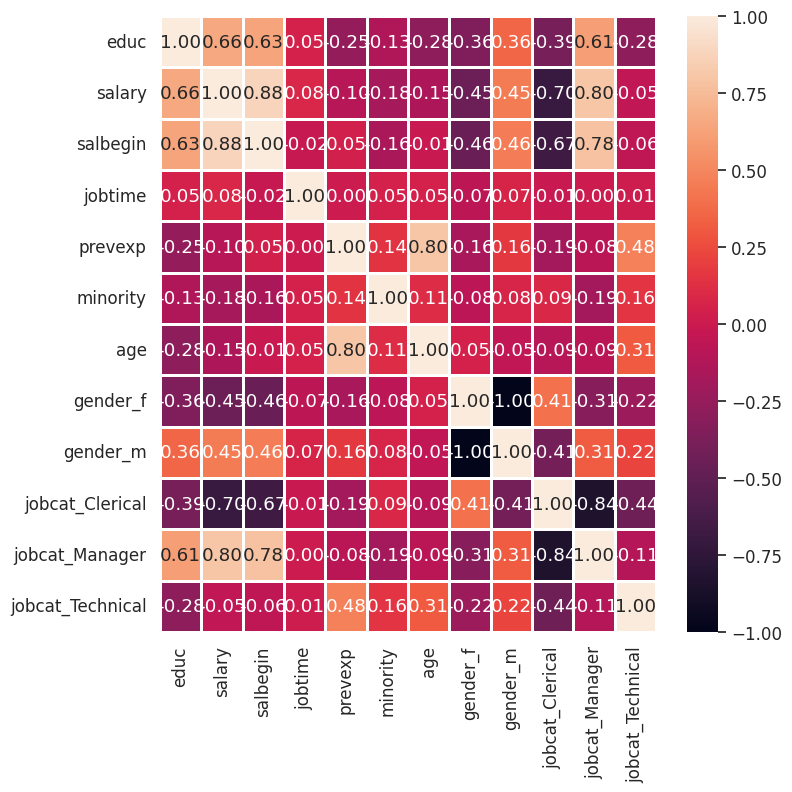

In [13]:
# Heatmap to show correlation between explanatory variables
sns.set(font_scale=1.1)
fig, ax = plt.subplots(figsize=(8,8))         # Sample figsize in inches
sns.heatmap(df.corr(), annot=True, fmt=".2f", linewidths=1, ax=ax)

## Computation of the PCA <a id="pca" />

Let's "fit" the PCA algorithm (in other words, let's compute the singular value decomposition)
<BR> Fit does the SVD (single vector decomposition) and transform applies parameters to project data into new space.
(k variables = d dimensions, we have not yet applied any "reduction").

In [14]:
sklearn_pca = PCA()
Y_sklearn = sklearn_pca.fit_transform(X_std)

Here the PCA is a full Singular Value Decomposition (SVD) (k variables = d dimensions, we have not yet applied any "reduction").

## Display of the explained variance of the eigenvectors. <a id="explained-variance" />

The first thing to do after fitting a PCA algorihtm is to plot the **explained variance** of each eigenvector (how much information from the original data each vector contain).

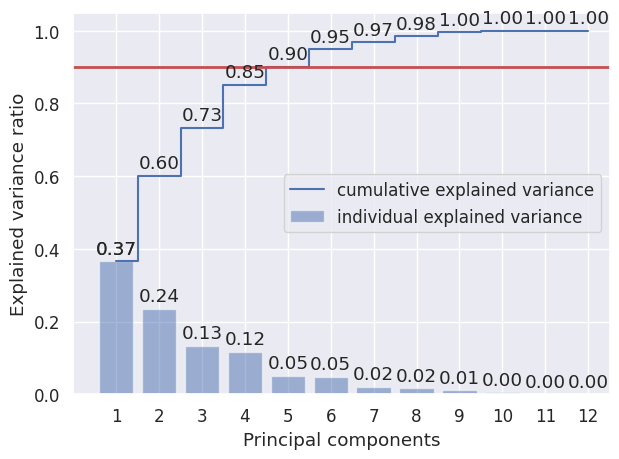

In [15]:
plt.bar(range(1,sklearn_pca.n_components_+1), sklearn_pca.explained_variance_ratio_, alpha=0.5, align='center',label='individual explained variance')
plt.step(range(1,sklearn_pca.n_components_+1), [sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)], where='mid',label='cumulative explained variance')
plt.axhline(y=0.90, linewidth=2, color = 'r')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
for i, ratio in enumerate(sklearn_pca.explained_variance_ratio_):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')
for i, ratio in enumerate([sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)]):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')

plt.xlim([0, sklearn_pca.n_components_+0.5])
plt.xticks(range(1, sklearn_pca.n_components_ + 1))
plt.legend(loc='best')
plt.tight_layout()


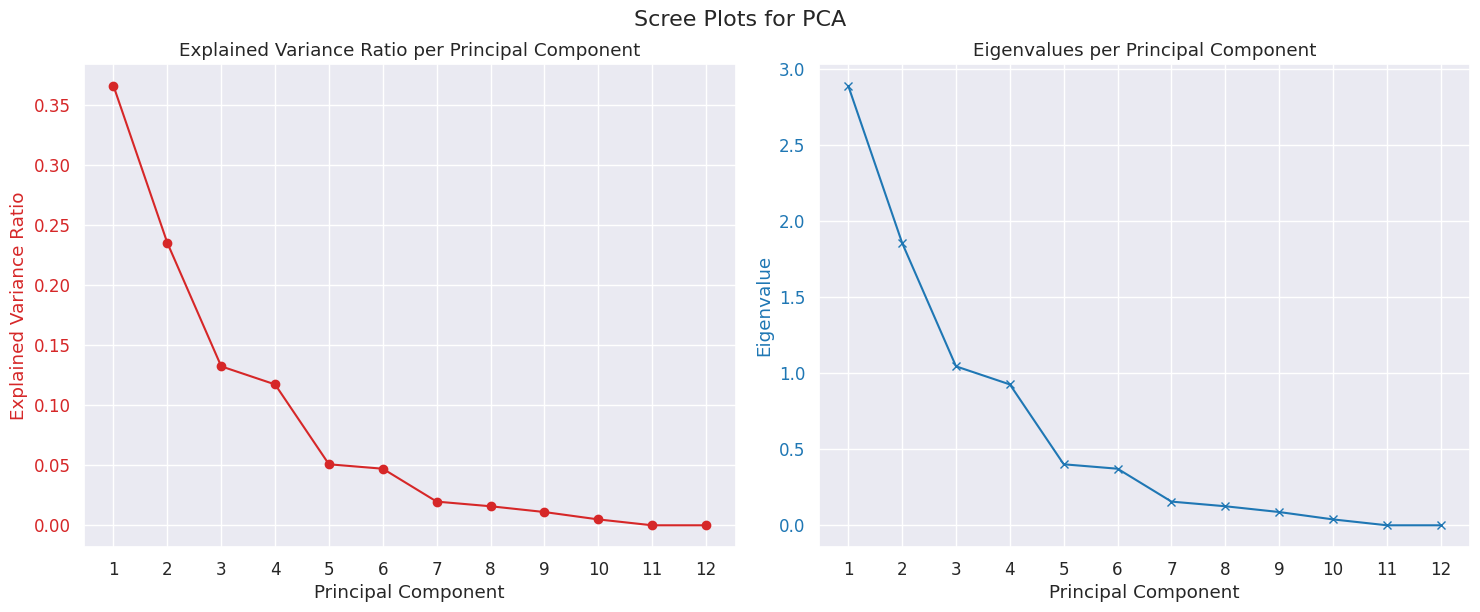

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Explained Variance Ratio
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio', color='tab:red')
ax1.plot(range(1, len(sklearn_pca.explained_variance_ratio_) + 1), sklearn_pca.explained_variance_ratio_, c='tab:red', marker='o', label='Explained Variance Ratio')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticks(range(1, len(sklearn_pca.explained_variance_ratio_) + 1))
ax1.set_title('Explained Variance Ratio per Principal Component')

# Plot 2: Eigenvalues
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Eigenvalue', color='tab:blue')
ax2.plot(range(1, len(sklearn_pca.explained_variance_) + 1), sklearn_pca.explained_variance_, c='tab:blue', marker='x', label='Eigenvalue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_xticks(range(1, len(sklearn_pca.explained_variance_) + 1))
ax2.set_title('Eigenvalues per Principal Component')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.suptitle('Scree Plots for PCA', y=1.02, fontsize=16) # Overall title
plt.show()

## Retaining only some vectors <a id="final-pca" />

Now you should decide how many of these vectors (in order) must be used to retain a proportion of
the variance of the original dataset accordingly <BR>(change that figure (0.65) below)

In [17]:
VARIANCE_TO_KEEP = 0.65 # that would mean two componentes in our example
keep_recommend = [sklearn_pca.explained_variance_ratio_[:y].sum()>VARIANCE_TO_KEEP for y in range(1,sklearn_pca.n_components_+1)].count(False)
print("Number of components to keep to retain %s%% of the variance:" % (100*VARIANCE_TO_KEEP), keep_recommend, "out of the original", sklearn_pca.n_components_)
n_components = keep_recommend

Number of components to keep to retain 65.0% of the variance: 2 out of the original 12


Let's run the PCA again but with the  number of components we have chosen this time

In [18]:
sklearn_pca_final = PCA(n_components)
Y_sklearn = sklearn_pca_final.fit_transform(X_std)

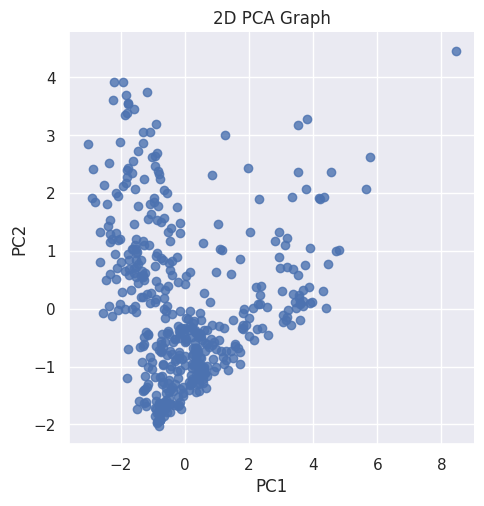

In [ ]:
# Create dataframe of two components to display them
# We have already applied PCA before with the optimal number of components, but we reapply
# PCA specifying two components, just in case the optimal number of components changes in later iterations
sklearn_pca_2 = PCA(n_components=2)
Y_sklearn_2 = sklearn_pca_2.fit_transform(X_std)
indx=np.arange(1, Y_sklearn_2.shape[0]+1)

pca_df_2 = pd.DataFrame(
    data=Y_sklearn_2,
    columns=['PC1', 'PC2'])

sns.set()
sns.lmplot(
    x='PC1',
    y='PC2',
    data=pca_df_2,
    fit_reg=False,
    legend=True
    )

plt.title('2D PCA Graph')
plt.show()

## Visualizing the eigenvectors in the original feature space <a id="original-space" />

Do we observe natural groupings? How spread is our data? Are there any outliers? What do observations that are together mean?

### Decomposition heatmap

Each of our eigenvectors has a linear decomposition in the original feature space.

To understand which features were the most important, we can see how our eigenvectors are made of each original feature.

In [ ]:
# Shows Factor loadings = correlations between variables and components
print("\nFactor loadings:")

pd.set_option('display.float_format', '{:.4f}'.format)

dfloadings=pd.DataFrame(
    data    = sklearn_pca_final.components_,
    columns = df.columns, # Use the columns from the processed df
)

index_list=[]
for n in range(n_components):
    index_list.append("PC"+str(n+1))

dfloadings.index = index_list

# Hide low values so that it is clearer
# We use dfloadings.T to transpose for easier viewing and filtering
display(dfloadings.T.where(abs(dfloadings.T) > 0.25, ""))  # we hide values lower than 0.25 to better display the relations


Factor loadings:


,PC1,PC2
educ,0.4934,
salary,0.5439,
salbegin,0.5175,0.2549
jobtime,,
prevexp,,0.6644
minority,,
age,,0.6322
gender_f,,
gender_m,,
jobcat_Clerical,,


## Assess the solution

Do you see any variable that must be removed?
If so, we would have to start from scratch

If not, are we able to set up component labels?

### Communalities
In order to calculate communalities (% of information explained from each variable), we need to square the loadings of each variable.

In [ ]:
# Communalities
commun=[]

# Ensure we iterate over the correct number of components selected (n_components)
for col in dfloadings.columns:
    # Sum of squares of loadings for each variable across the selected principal components
    commun.append((dfloadings.loc[[f'PC{i+1}' for i in range(n_components)], col]**2).sum())

dfcommun = pd.DataFrame(commun,index=dfloadings.columns, columns=["Communalities"])
display(dfcommun.sort_values("Communalities", ascending=False))

,Communalities
prevexp,0.4691
age,0.4410
salbegin,0.3327
salary,0.3194
educ,0.2446
minority,0.0416
jobcat_Clerical,0.0409
jobcat_Manager,0.0361
gender_f,0.0319
gender_m,0.0319


### Component plot

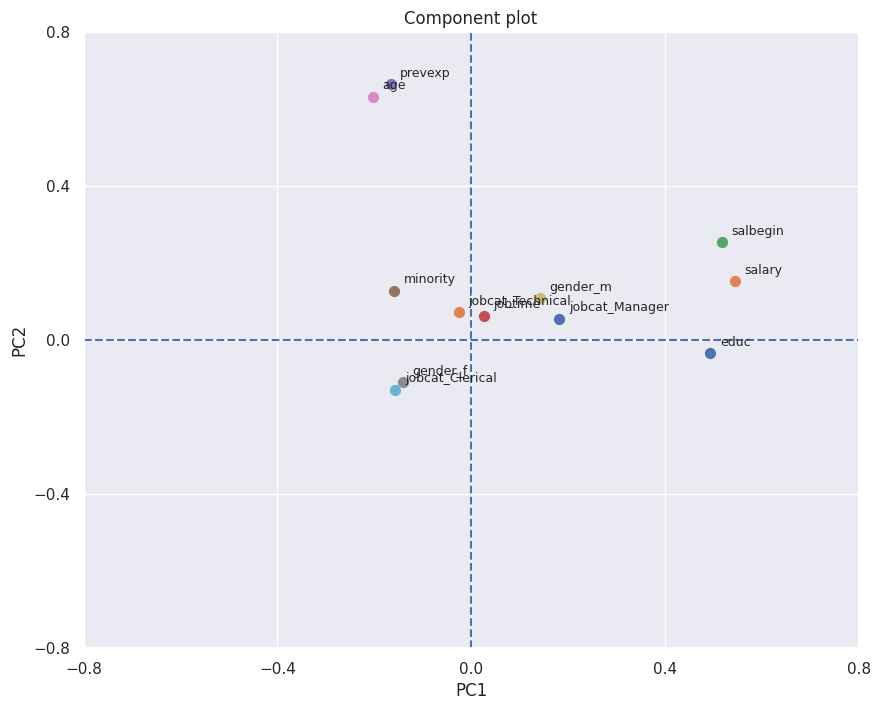

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the loadings of x and y axes
dfloadT = dfloadings.T

xs = dfloadT.PC1
ys = dfloadT.PC2

plt.figure(figsize=(10, 8))
plt.axvline(x=0, color='b', linestyle='dashed')
plt.axhline(y=0, color='b', linestyle='dashed')

# Plot the loadings on a scatterplot
for i, varnames in enumerate(dfloadings.columns):
    plt.scatter(xs.iloc[i], ys.iloc[i], s=50)

    # Slightly offset the text to avoid overlap
    plt.text(xs.iloc[i] + 0.02, ys.iloc[i] + 0.02, varnames, fontsize=9)

# Define the axes and show plot
xticks = np.linspace(-0.8, 0.8, num=5)
yticks = np.linspace(-0.8, 0.8, num=5)
plt.xticks(xticks)
plt.yticks(yticks)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Component plot')

# Save the plot and show it
plt.savefig('Component_plot.png', bbox_inches='tight')  # Avoid cutting parts off
plt.show()

### Visualizing relation between 2 projected vectors

In [ ]:
# Data Projections can also be shown
pca_df_2

,PC1,PC2
0,2.0140,1.3213
1,1.0442,-0.3019
2,-2.0156,2.8904
3,-1.9921,0.7994
4,0.9598,0.6358
...,...,...
469,-0.7228,-0.4431
470,-0.0937,-0.8735
471,0.6714,-0.9857
472,-1.5356,0.7232


And we combine original data with components created and export all to Excel

In [ ]:
frames = [df_orig, pca_df_2]
df_norot = pd.concat(frames,axis=1)
df_norot.to_excel("Final_norotations.xlsx")

## Rotations
We apply one rotation method. Rotations  are applied to find a clearer structure of the underlying factors in the data.
<BR> Varimax mximizes the variances of the factor loadings to try  each variable has a high loading on a single factor.


In [ ]:
!pip install factor_analyzer
from factor_analyzer import Rotator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=d84a574d5c7c8c19f6e0754473e1df85f424fb8ed62cea3f407f83a4922fb425
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
rotator = Rotator(method='varimax')
# Transpose dfloadings so features are rows and components are columns for the rotator
rotated_loadings = rotator.fit_transform(dfloadings.T)

# Create a DataFrame from the rotated loadings
df_varimax = pd.DataFrame(rotated_loadings, columns = [f'PC{i+1}' for i in range(n_components)], index=df.columns)

print("\nVarimax rotation: ")
display(df_varimax.where(abs(df_varimax) > 0.25  , ""))


Varimax rotation: 


,PC1,PC2
educ,0.4378,
salary,0.5596,
salbegin,0.5763,
jobtime,,
prevexp,,0.6751
minority,,
age,,0.6605
gender_f,,
gender_m,,
jobcat_Clerical,,


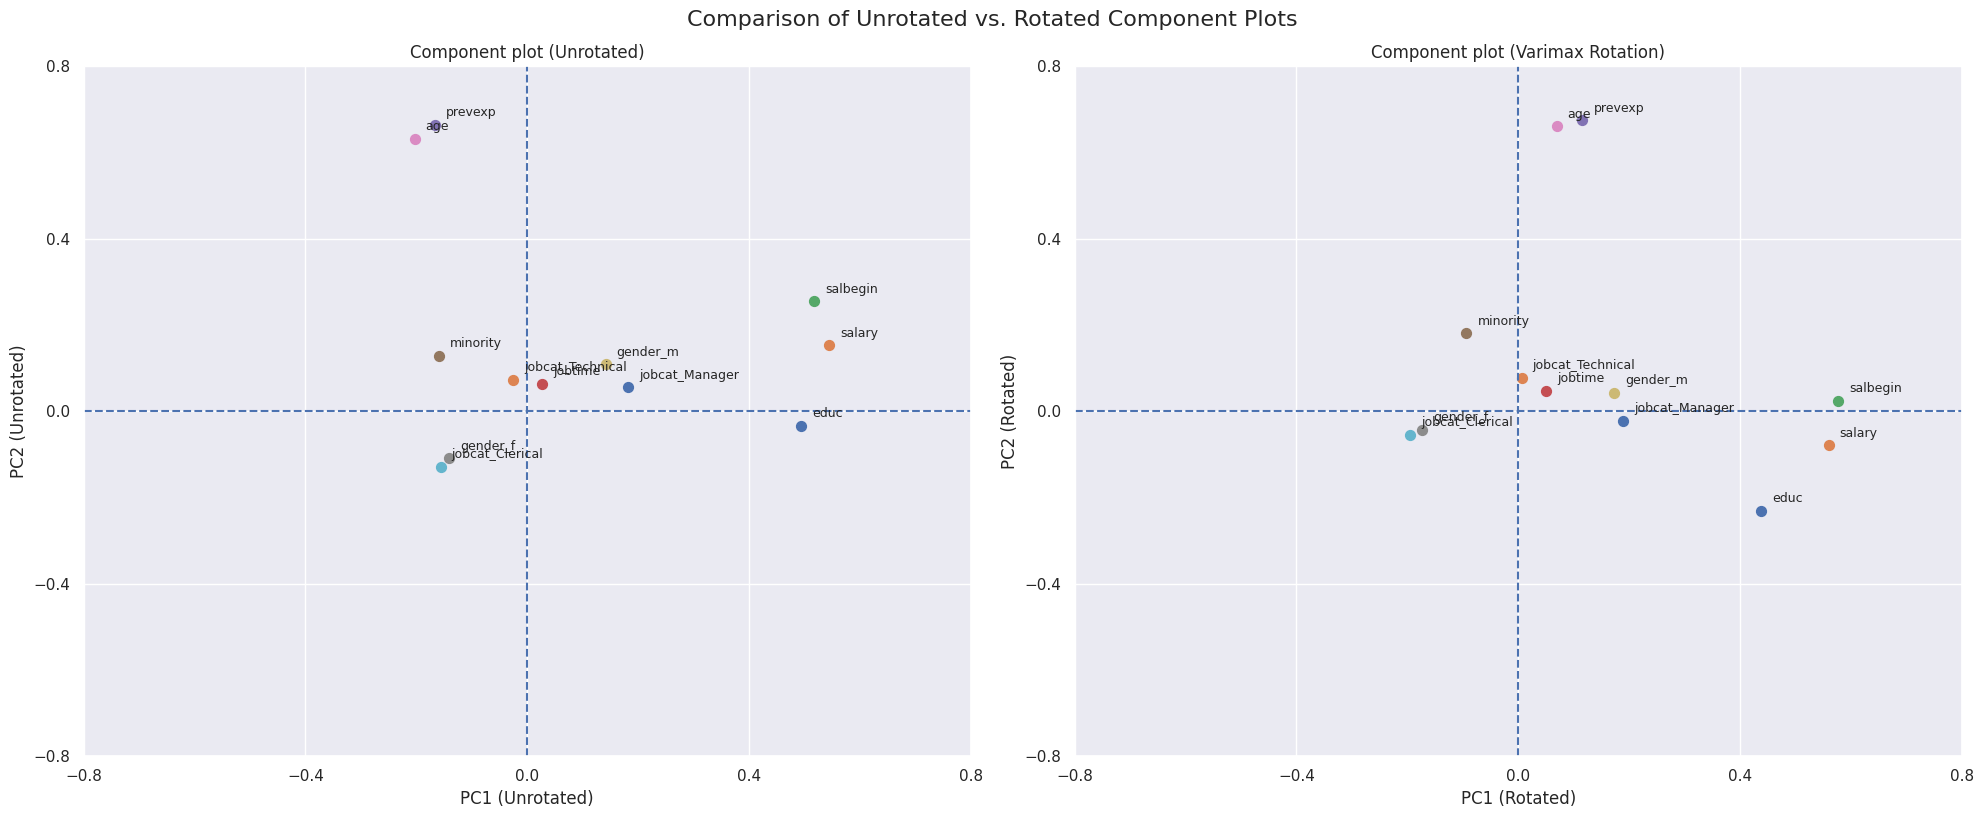

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot for Unrotated Components ---
xs_unrotated = dfloadings.T.PC1
ys_unrotated = dfloadings.T.PC2

ax1.axvline(x=0, color='b', linestyle='dashed')
ax1.axhline(y=0, color='b', linestyle='dashed')

for i, varnames in enumerate(dfloadings.columns):
    ax1.scatter(xs_unrotated.iloc[i], ys_unrotated.iloc[i], s=50, label=varnames)
    ax1.text(xs_unrotated.iloc[i] + 0.02, ys_unrotated.iloc[i] + 0.02, varnames, fontsize=9)

ax1.set_xticks(np.linspace(-0.8, 0.8, num=5))
ax1.set_yticks(np.linspace(-0.8, 0.8, num=5))
ax1.set_xlabel('PC1 (Unrotated)')
ax1.set_ylabel('PC2 (Unrotated)')
ax1.set_title('Component plot (Unrotated)')

# --- Plot for Varimax Rotated Components ---
xs_rotated = df_varimax.PC1
ys_rotated = df_varimax.PC2

ax2.axvline(x=0, color='b', linestyle='dashed')
ax2.axhline(y=0, color='b', linestyle='dashed')

for i, varnames in enumerate(df_varimax.index):
    ax2.scatter(xs_rotated.iloc[i], ys_rotated.iloc[i], s=50, label=varnames)
    ax2.text(xs_rotated.iloc[i] + 0.02, ys_rotated.iloc[i] + 0.02, varnames, fontsize=9)

ax2.set_xticks(np.linspace(-0.8, 0.8, num=5))
ax2.set_yticks(np.linspace(-0.8, 0.8, num=5))
ax2.set_xlabel('PC1 (Rotated)')
ax2.set_ylabel('PC2 (Rotated)')
ax2.set_title('Component plot (Varimax Rotation)')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.suptitle('Comparison of Unrotated vs. Rotated Component Plots', y=1.02, fontsize=16)
plt.savefig('Comparison_Component_plots.png')
plt.show()

## Questions

To demonstrate your understanding of this PCA exercise, please answer the following questions:

1.  What is the primary goal of Principal Component Analysis (PCA)?
2.  Why is data standardization a crucial preprocessing step before applying PCA?
3.  Based on the "Explained Variance Ratio" plot, how many principal components would you recommend keeping to retain at least 80% of the variance? Justify your answer.
4.  Explain the concept of "factor loadings" and how they help in interpreting the principal components.
5.  Describe the purpose of "Varimax rotation" in PCA. How does it change the factor loadings, and what benefit does it provide for interpretation?
6. Variables with communalities lower than 0.2 or 0.3 can be dropped, unless downsream models use them, or there is a theoretical reason to keep them. We could aim at explaining a higher percentage of variance than 65% (lets say, 80%). Try the PCA again excluding low communality variables and that outlier, and aim to explain 80% of the variability. Does it improve interpretability?

1. Primary goal of PCA is to reduce the number of features
2. It brings features with different scale values in a similar range
3. 4 as the explained variance adds upto 85%
4. Factor loading tells us how strongly each feature contribute to the principal components, based on the features contributing the most to certain components we can explain the components